In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

GITHUB_REPO = "https://github.com/danokundaye/kidney-tumour-detection.git"
REPO_NAME = "kidney-tumour-detection"
CLONE_PATH = f"/content/{REPO_NAME}"

if os.path.exists(CLONE_PATH):
    print("Repository already exists, pulling latest changes...")
    os.chdir(CLONE_PATH)
    os.system("git pull origin main")
    print("Repository updated")
else:
    print("Cloning repository...")
    os.system(f"git clone {GITHUB_REPO} {CLONE_PATH}")
    print("Repository cloned")

if CLONE_PATH not in sys.path:
    sys.path.insert(0, CLONE_PATH)
    print(f"Added {CLONE_PATH} to Python path")

print(f"\nWorking directory: {CLONE_PATH}")
print("GitHub sync complete")

Mounted at /content/drive
Cloning repository...
Repository cloned
Added /content/kidney-tumour-detection to Python path

Working directory: /content/kidney-tumour-detection
GitHub sync complete


In [5]:
# Step 6.7 — U-Net Inference Visualisation
import os
os.chdir("/content/kidney-tumour-detection")
!git pull origin main

!pip install segmentation-models-pytorch -q

!python /content/kidney-tumour-detection/src/segmentation/unet_inference.py

fatal: not a git repository (or any of the parent directories): .git
Step 6.7 — U-Net Inference Visualisation

Model loaded from best.pt. Device: cuda
Cases: 100% 24/24 [03:00<00:00,  7.50s/it]

Cases visualised : 7
Overall mean Dice: 0.2458
Output saved to  : /content/drive/MyDrive/kidney-tumour-detection/results/phase6_unet/visualizations

Per-case summary:
   case_id abnormality  slices_shown  mean_dice
case_00295      tumour             8     0.4602
case_00213      tumour             8     0.3221
case_00188        cyst             1     0.0000
case_00271      tumour             8     0.2944
case_00216      tumour             8     0.5696
case_00152      tumour             8     0.0743
case_00187      tumour             8     0.0000

 Done.


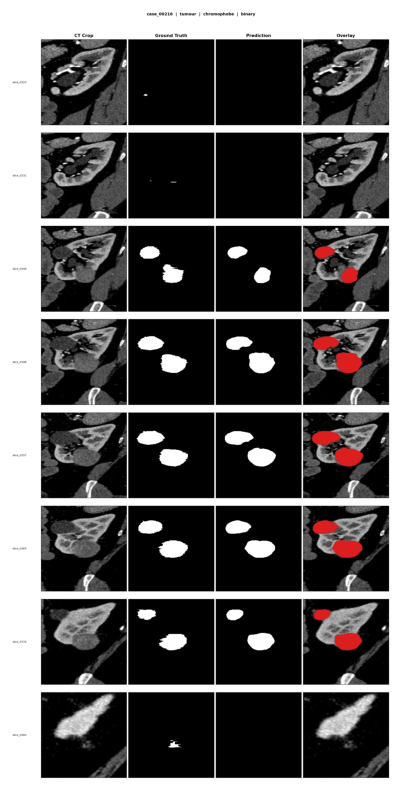

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/kidney-tumour-detection/results/phase6_unet/visualizations/binary/case_00216_binary.png")
plt.figure(figsize=(20, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

In [6]:
# Step 7.1 - Patch Preparation
import os
os.chdir("/content/kidney-tumour-detection")
!git pull origin main

!pip install segmentation-models-pytorch -q

!python /content/kidney-tumour-detection/src/classification/patch_preparation.py

From https://github.com/danokundaye/kidney-tumour-detection
 * branch            main       -> FETCH_HEAD
Already up to date.
Step 7.1 — EfficientNet Patch Preparation
Cases with unet_crops content : 33
Cases using raw slices        : estimated 87
U-Net loaded. Device: cuda

[unet_crops] Processing 33 cases...
unet_crops cases: 100% 33/33 [38:46<00:00, 70.51s/it]

[abnormal tissue missing crops] Processing 87 cases from raw slices...
missing abnormal crop cases: 100% 87/87 [1:40:40<00:00, 69.43s/it]
Patch Preparation Complete
Total patches : 4987

By class:
malignant
malignant    4810
benign        177
Name: count, dtype: int64

By source:
source
gt      4081
unet     906
Name: count, dtype: int64

Mean Dice (U-Net sourced patches): 0.8491

Index saved to: /content/drive/MyDrive/kidney-tumour-detection/dataset/processed/splits/patches_index.csv

Done.


In [29]:
import pandas as pd
from pathlib import Path

patches_index = pd.read_csv("/content/drive/MyDrive/kidney-tumour-detection/dataset/processed/splits/patches_index.csv")
seg_df        = pd.read_csv("/content/drive/MyDrive/kidney-tumour-detection/dataset/processed/splits/segmentation_train.csv")

cases_with_patches = set(patches_index['case_id'].unique())
all_seg_cases      = set(seg_df['case_id'].unique())
missing            = all_seg_cases - cases_with_patches

print(f"Cases with patches : {len(cases_with_patches)}")
print(f"Cases without patches : {len(missing)}")
print(f"\nMissing cases: {sorted(missing)}")

Cases with patches : 98
Cases without patches : 22

Missing cases: ['case_00010', 'case_00020', 'case_00031', 'case_00043', 'case_00062', 'case_00087', 'case_00121', 'case_00122', 'case_00129', 'case_00136', 'case_00137', 'case_00148', 'case_00161', 'case_00163', 'case_00167', 'case_00177', 'case_00182', 'case_00205', 'case_00239', 'case_00259', 'case_00269', 'case_00277']


In [30]:
from pathlib import Path
import numpy as np
from PIL import Image

slices_dir = Path("/content/drive/MyDrive/kidney-tumour-detection/dataset/processed/slices/segmentation_train")

for case_id in ['case_00010', 'case_00020', 'case_00031']:
    masks_dir = slices_dir / case_id / "masks"
    found = 0
    for f in sorted(masks_dir.glob("*.png")):
        m = np.array(Image.open(f).convert("L"))
        if np.any(m == 170) or np.any(m == 255):
            abnormal = (m == 170) | (m == 255)
            rows = np.any(abnormal, axis=1)
            cols = np.any(abnormal, axis=0)
            rmin, rmax = np.where(rows)[0][[0, -1]]
            cmin, cmax = np.where(cols)[0][[0, -1]]
            h = rmax - rmin
            w = cmax - cmin
            print(f"{case_id} {f.name}: tumour region {h}x{w} pixels")
            found += 1
        if found >= 5:
            break
    if found == 0:
        print(f"{case_id}: no abnormal slices found in loop")

case_00010 slice_0291.png: tumour region 0x4 pixels
case_00010 slice_0292.png: tumour region 2x15 pixels
case_00010 slice_0293.png: tumour region 4x20 pixels
case_00010 slice_0294.png: tumour region 5x24 pixels
case_00010 slice_0295.png: tumour region 7x28 pixels
case_00020 slice_0310.png: tumour region 1x5 pixels
case_00020 slice_0311.png: tumour region 1x10 pixels
case_00020 slice_0312.png: tumour region 2x14 pixels
case_00020 slice_0313.png: tumour region 2x17 pixels
case_00020 slice_0314.png: tumour region 3x18 pixels
case_00031 slice_0330.png: tumour region 2x14 pixels
case_00031 slice_0331.png: tumour region 3x18 pixels
case_00031 slice_0332.png: tumour region 4x21 pixels
case_00031 slice_0333.png: tumour region 5x24 pixels
case_00031 slice_0334.png: tumour region 6x25 pixels


In [31]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/kidney-tumour-detection/dataset/processed/splits/patches_index.csv")
benign_df = df[df['malignant'] == False]
print(benign_df.groupby('case_id')['slice_name'].count().reset_index()
      .rename(columns={'slice_name': 'patch_count'}))

      case_id  patch_count
0  case_00116           23
1  case_00156           52
2  case_00188            1
3  case_00258           51
4  case_00275           50


In [35]:
# Step 7.2 - Patient-level Train/Val Split
import os
os.chdir("/content/kidney-tumour-detection")
!git pull origin main

!python /content/kidney-tumour-detection/src/classification/patch_split.py

From https://github.com/danokundaye/kidney-tumour-detection
 * branch            main       -> FETCH_HEAD
Already up to date.
Step 7.2 — EfficientNet Train/Val Split

Benign split:
  Train cases : ['case_00188', 'case_00258', 'case_00275', 'case_00116']
  Val cases   : ['case_00156']

Malignant split:
  Train cases : 74
  Val cases   : 19

Train set:
  Total patches  : 3952
  Malignant      : 3827
  Benign         : 125
  Benign cases   : 4

Val set:
  Total patches  : 1035
  Malignant      : 983
  Benign         : 52
  Benign cases   : 1

Splits saved to: /content/drive/MyDrive/kidney-tumour-detection/dataset/processed/splits

Done.


In [10]:
# Copy patch folders from drive to local storage
import os
from pathlib import Path

drive_patches = Path("/content/drive/MyDrive/kidney-tumour-detection/dataset/processed/patches")
local_patches = Path("/content/patches")
local_patches.mkdir(exist_ok=True)

cases = sorted(drive_patches.iterdir())
print(f"Copying {len(cases)} case folders to local storage...")

for i, case_dir in enumerate(cases):
    src = str(case_dir) + "/"
    dst = str(local_patches / case_dir.name) + "/"
    os.system(f"rsync -a '{src}' '{dst}'")
    print(f"  {i+1}/{len(cases)}: {case_dir.name} done")

print("\nCopy complete.")

Copying 98 case folders to local storage...
  1/98: case_00002 done
  2/98: case_00006 done
  3/98: case_00012 done
  4/98: case_00015 done
  5/98: case_00016 done
  6/98: case_00022 done
  7/98: case_00025 done
  8/98: case_00026 done
  9/98: case_00032 done
  10/98: case_00033 done
  11/98: case_00037 done
  12/98: case_00040 done
  13/98: case_00063 done
  14/98: case_00065 done
  15/98: case_00068 done
  16/98: case_00074 done
  17/98: case_00079 done
  18/98: case_00081 done
  19/98: case_00083 done
  20/98: case_00084 done
  21/98: case_00086 done
  22/98: case_00090 done
  23/98: case_00095 done
  24/98: case_00101 done
  25/98: case_00103 done
  26/98: case_00107 done
  27/98: case_00108 done
  28/98: case_00109 done
  29/98: case_00110 done
  30/98: case_00115 done
  31/98: case_00116 done
  32/98: case_00118 done
  33/98: case_00119 done
  34/98: case_00123 done
  35/98: case_00125 done
  36/98: case_00126 done
  37/98: case_00128 done
  38/98: case_00131 done
  39/98: case_0

In [14]:
# Step 7.3 - EfficientNet-B0 Training
import os
os.chdir("/content/kidney-tumour-detection")
!git pull origin main

!python /content/kidney-tumour-detection/src/classification/efficientnet_train.py

From https://github.com/danokundaye/kidney-tumour-detection
 * branch            main       -> FETCH_HEAD
Already up to date.
Step 7.3 — EfficientNet-B0 Classification Training
Device: cuda

Train patches : 3952 (3827 mal, 125 ben)
Val patches   : 1035 (983 mal, 52 ben)
Oversample factor (benign): 15x
Benign class weight: 30.62
Epoch 001/50 | Loss 3.3392/0.7304 | Acc 0.7361/0.9498 | F1_mal 0.9742 | F1_ben 0.0000 | Sens 1.0000 | Spec 0.0000
 Best model saved (mean F1: 0.4871)
Epoch 002/50 | Loss 0.5904/0.7062 | Acc 0.8365/0.9498 | F1_mal 0.9742 | F1_ben 0.0000 | Sens 1.0000 | Spec 0.0000
Epoch 003/50 | Loss 0.3705/0.6861 | Acc 0.9111/0.9459 | F1_mal 0.9722 | F1_ben 0.0000 | Sens 0.9959 | Spec 0.0000
Epoch 004/50 | Loss 0.3093/0.5962 | Acc 0.9369/0.9459 | F1_mal 0.9722 | F1_ben 0.0000 | Sens 0.9959 | Spec 0.0000
Epoch 005/50 | Loss 0.2638/0.6919 | Acc 0.9390/0.9459 | F1_mal 0.9722 | F1_ben 0.0000 | Sens 0.9959 | Spec 0.0000
Epoch 006/50 | Loss 0.1291/0.8810 | Acc 0.9742/0.9449 | F1_mal 0

In [15]:
# Step 7.2 - Patient-level Train/Val Split (Malignant cap included)
import os
os.chdir("/content/kidney-tumour-detection")
!git pull origin main

!python /content/kidney-tumour-detection/src/classification/patch_split.py

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 7 (delta 5), reused 7 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 763 bytes | 763.00 KiB/s, done.
From https://github.com/danokundaye/kidney-tumour-detection
 * branch            main       -> FETCH_HEAD
   bc8e2c9..ec23687  main       -> origin/main
Updating bc8e2c9..ec23687
Fast-forward
 configs/config.yaml               | 7 ++++---
 src/classification/patch_split.py | 5 +++++
 2 files changed, 9 insertions(+), 3 deletions(-)
Step 7.2 — EfficientNet Train/Val Split

Benign split:
  Train cases : ['case_00188', 'case_00258', 'case_00275', 'case_00116']
  Val cases   : ['case_00156']

Malignant split:
  Train cases : 74
  Val cases   : 19

Train set:
  Total patches  : 500
  Malignant      : 375
  Benign         : 125
  Benign cases   : 4

Val set:
  Total patches  : 1035
  Malignant      : 983
  Benign         : 52
  Ben

In [17]:
# Step 7.3 - EfficientNet-B0 Training (Malignant cap)
import os
os.chdir("/content/kidney-tumour-detection")
!git pull origin main

!python /content/kidney-tumour-detection/src/classification/efficientnet_train.py

From https://github.com/danokundaye/kidney-tumour-detection
 * branch            main       -> FETCH_HEAD
Already up to date.
Step 7.3 — EfficientNet-B0 Classification Training
Device: cuda

Train patches : 500 (375 mal, 125 ben)
Val patches   : 1035 (983 mal, 52 ben)
Oversample factor (benign): 15x
Benign class weight: 3.00
Epoch 001/50 | Loss 0.8900/1.8920 | Acc 0.6036/0.6831 | F1_mal 0.8048 | F1_ben 0.1590 | Sens 0.6877 | Spec 0.5962
 Best model saved (mean F1: 0.4819)
Epoch 002/50 | Loss 0.8166/1.8510 | Acc 0.7698/0.7150 | F1_mal 0.8282 | F1_ben 0.1643 | Sens 0.7233 | Spec 0.5577
 Best model saved (mean F1: 0.4962)
Epoch 003/50 | Loss 0.7581/1.6936 | Acc 0.8031/0.7961 | F1_mal 0.8831 | F1_ben 0.2038 | Sens 0.8108 | Spec 0.5192
 Best model saved (mean F1: 0.5434)
Epoch 004/50 | Loss 0.6802/1.5528 | Acc 0.8573/0.8106 | F1_mal 0.8929 | F1_ben 0.1833 | Sens 0.8311 | Spec 0.4231
Epoch 005/50 | Loss 0.6248/1.3444 | Acc 0.8751/0.8300 | F1_mal 0.9053 | F1_ben 0.1698 | Sens 0.8555 | Spec 0.

In [21]:
# Step 7.3 - EfficientNet-B0 Evaluation (Malignant cap)
import os
os.chdir("/content/kidney-tumour-detection")
!git pull origin main

!python /content/kidney-tumour-detection/src/classification/efficientnet_eval.py

From https://github.com/danokundaye/kidney-tumour-detection
 * branch            main       -> FETCH_HEAD
Already up to date.
Step 7.4 — EfficientNet-B0 Evaluation
Device: cuda

Val patches : 1035 (983 mal, 52 ben)
Loaded checkpoint from epoch 6
Checkpoint val F1: 0.5637
Final Validation Metrics
Accuracy    : 0.858
F1 Malignant: 0.922
F1 Benign   : 0.2054
Sensitivity : 0.884  (malignant recall)
Specificity : 0.3654  (benign recall)
AUC         : 0.8291

Confusion Matrix:
              Predicted
              Benign  Malignant
Actual Benign     19       33
Actual Malignant 114      869

Classification Report:
              precision    recall  f1-score   support

      benign       0.14      0.37      0.21        52
   malignant       0.96      0.88      0.92       983

    accuracy                           0.86      1035
   macro avg       0.55      0.62      0.56      1035
weighted avg       0.92      0.86      0.89      1035

Metrics saved to: /content/drive/MyDrive/kidney-tumour-de

In [22]:
# Step 7.3 - EfficientNet-B0 Training (Balanced)
import os
os.chdir("/content/kidney-tumour-detection")
!git pull origin main

!python /content/kidney-tumour-detection/src/classification/efficientnet_balanced.py

remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 3.17 KiB | 3.17 MiB/s, done.
From https://github.com/danokundaye/kidney-tumour-detection
 * branch            main       -> FETCH_HEAD
   fdce118..f0e2030  main       -> origin/main
Updating fdce118..f0e2030
Fast-forward
 src/classification/efficientnet_balanced.py | 220 ++++++++++++++++++++++++++++
 1 file changed, 220 insertions(+)
 create mode 100644 src/classification/efficientnet_balanced.py
Balanced train : 250 patches
malignant
benign       125
malignant    125
Name: count, dtype: int64
Val            : 1035 patches

Balanced 1:1 Experiment — EfficientNet-B0
Device: cuda
Epoch 001/50 | Loss 0.6837/0.7427 | Acc 0.5920/0.3449 | F1_mal 0.4817 | F1_ben 0.1102 | Sens 0.3204 | Spec 0.8077
  ✓ Best model saved (mean F1: 0.2959)
Epoch 002/50 | Loss 0.6820/0.737

In [24]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import (f1_score, accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report)
from pathlib import Path
from PIL import Image
import yaml
import json

# Config
with open("/content/kidney-tumour-detection/configs/config.yaml") as f:
    config = yaml.safe_load(f)

splits_dir    = Path(config['paths']['splits_dir'])
results_dir   = Path(config['paths']['results_dir']) / "phase7_efficientnet_balanced_retrain_weighted"
weights_dir   = results_dir / "weights"
metrics_dir   = results_dir / "metrics"
patches_dir   = Path(config['paths']['patches_dir'])
local_patches = Path("/content/patches")
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

# Balanced train set
train_df     = pd.read_csv(splits_dir / "efficientnet_train.csv")
val_df       = pd.read_csv(splits_dir / "efficientnet_val.csv")

malignant_df = train_df[train_df['malignant'] == True].sample(n=125, random_state=42)
benign_df    = train_df[train_df['malignant'] == False]
train_df     = pd.concat([malignant_df, benign_df], ignore_index=True)
train_df     = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced train : {len(train_df)} patches")
print(train_df['malignant'].value_counts().rename({True: 'malignant', False: 'benign'}))
print(f"Val            : {len(val_df)} patches")

# Dataset
class PatchDataset(Dataset):
    def __init__(self, df, local_patches_dir, drive_patches_dir,
                 augment=False, oversample_factor=1):
        self.local_patches_dir = Path(local_patches_dir)
        self.drive_patches_dir = str(drive_patches_dir)
        df = df.copy()
        df['local_path'] = df['patch_path'].apply(self._remap_path)

        if oversample_factor > 1:
            benign_df    = df[df['malignant'] == False]
            malignant_df = df[df['malignant'] == True]
            benign_df    = pd.concat([benign_df] * oversample_factor, ignore_index=True)
            df           = pd.concat([malignant_df, benign_df], ignore_index=True)
            df           = df.sample(frac=1, random_state=42).reset_index(drop=True)

        self.df      = df
        self.augment = augment

        self.train_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485], std=[0.229]),
        ])
        self.val_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485], std=[0.229]),
        ])

    def _remap_path(self, drive_path):
        return drive_path.replace(self.drive_patches_dir, str(self.local_patches_dir))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['local_path']).convert("L")
        label = torch.tensor(float(row['malignant']), dtype=torch.float32)
        img   = self.train_transform(img) if self.augment else self.val_transform(img)
        img   = img.repeat(3, 1, 1)
        return img, label

# Model
def build_model(device):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, 1)
    )
    return model.to(device)

# Metrics
def compute_metrics(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = 0.0
    return {
        'accuracy'    : accuracy_score(labels, preds),
        'f1_malignant': f1_score(labels, preds, pos_label=1, zero_division=0),
        'f1_benign'   : f1_score(labels, preds, pos_label=0, zero_division=0),
        'sensitivity' : sensitivity,
        'specificity' : specificity,
        'auc'         : auc,
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
    }

# Epoch runner
def run_epoch(model, loader, criterion, optimizer, device, is_train):
    model.train() if is_train else model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs).squeeze(1)
            loss   = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(all_labels)
    metrics  = compute_metrics(np.array(all_labels), np.array(all_probs))
    return avg_loss, metrics

# Evaluation
def evaluate(model, loader, device, threshold, metrics_dir):
    """Run inference on val set and print/save final metrics."""
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            logits = model(imgs).squeeze(1)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(labels.numpy())

    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    metrics    = compute_metrics(all_labels, all_probs, threshold)
    all_preds  = (all_probs >= threshold).astype(int)

    print("\n" + "=" * 50)
    print("FINAL VALIDATION METRICS")
    print("=" * 50)
    print(f"Accuracy    : {metrics['accuracy']:.4f}")
    print(f"F1 Malignant: {metrics['f1_malignant']:.4f}")
    print(f"F1 Benign   : {metrics['f1_benign']:.4f}")
    print(f"Sensitivity : {metrics['sensitivity']:.4f}  (malignant recall)")
    print(f"Specificity : {metrics['specificity']:.4f}  (benign recall)")
    print(f"AUC         : {metrics['auc']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"                Predicted")
    print(f"                Benign  Malignant")
    print(f"Actual Benign     {metrics['tn']:4d}     {metrics['fp']:4d}")
    print(f"Actual Malignant  {metrics['fn']:4d}     {metrics['tp']:4d}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=['benign', 'malignant'],
                                zero_division=0))

    # Save
    with open(metrics_dir / "val_metrics.json", 'w') as f:
        json.dump({k: round(float(v), 4) for k, v in metrics.items()}, f, indent=2)

    pd.DataFrame({
        'actual'        : all_labels,
        'predicted'     : all_preds,
        'prob_malignant': all_probs,
    }).to_csv(metrics_dir / "val_predictions.csv", index=False)

    print(f"\nMetrics saved to: {metrics_dir}")

# Training
epochs      = config['efficientnet']['epochs']
batch_size  = config['efficientnet']['batch_size']
lr          = config['efficientnet']['learning_rate']
lr_patience = config['efficientnet']['lr_reduce_patience']
es_patience = config['efficientnet']['early_stopping_patience']
threshold   = config['efficientnet']['classification_threshold']
seed        = config['dataset']['random_seed']

torch.manual_seed(seed)
np.random.seed(seed)

train_dataset = PatchDataset(train_df, local_patches, patches_dir, augment=True)
val_dataset   = PatchDataset(val_df,   local_patches, patches_dir, augment=False)

train_loader  = DataLoader(train_dataset, batch_size=batch_size,
                           shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=batch_size,
                           shuffle=False, num_workers=2, pin_memory=True)

pos_weight = torch.tensor([3.0], dtype=torch.float32).to(device)
model      = build_model(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
scheduler  = ReduceLROnPlateau(optimizer, mode='max', patience=lr_patience, factor=0.5)

best_f1, epochs_no_improve, log_records = 0.0, 0, []

print("\nBalanced 1:1 Experiment — EfficientNet-B0")
print(f"Device: {device}")

for epoch in range(1, epochs + 1):
    train_loss, train_m = run_epoch(model, train_loader, criterion,
                                    optimizer, device, is_train=True)
    val_loss,   val_m   = run_epoch(model, val_loader,   criterion,
                                    optimizer, device, is_train=False)

    val_f1 = (val_m['f1_malignant'] + val_m['f1_benign']) / 2
    scheduler.step(val_f1)

    log_records.append({
        'epoch'           : epoch,
        'train_loss'      : round(train_loss, 4),
        'val_loss'        : round(val_loss, 4),
        'train_acc'       : round(train_m['accuracy'], 4),
        'val_acc'         : round(val_m['accuracy'], 4),
        'val_f1_malignant': round(val_m['f1_malignant'], 4),
        'val_f1_benign'   : round(val_m['f1_benign'], 4),
        'val_sensitivity' : round(val_m['sensitivity'], 4),
        'val_specificity' : round(val_m['specificity'], 4),
        'val_auc'         : round(val_m['auc'], 4),
    })

    print(f"Epoch {epoch:03d}/{epochs} | "
          f"Loss {train_loss:.4f}/{val_loss:.4f} | "
          f"Acc {train_m['accuracy']:.4f}/{val_m['accuracy']:.4f} | "
          f"F1_mal {val_m['f1_malignant']:.4f} | "
          f"F1_ben {val_m['f1_benign']:.4f} | "
          f"Sens {val_m['sensitivity']:.4f} | "
          f"Spec {val_m['specificity']:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model.state_dict(),
            'val_f1'          : best_f1,
            'val_metrics'     : val_m,
        }, weights_dir / "best_retrain.pt")
        print(f"  Best model saved (mean F1: {best_f1:.4f})")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= es_patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

    pd.DataFrame(log_records).to_csv(metrics_dir / "training_log.csv", index=False)

print(f"\nBest mean F1: {best_f1:.4f}")

# Load best and evaluate
ckpt = torch.load(weights_dir / "best_retrain.pt",
                  map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f"\nLoaded best checkpoint from epoch {ckpt['epoch']}")

evaluate(model, val_loader, device, threshold, metrics_dir)
print("\nDone.")

Balanced train : 250 patches
malignant
benign       125
malignant    125
Name: count, dtype: int64
Val            : 1035 patches

Balanced 1:1 Experiment — EfficientNet-B0
Device: cuda
Epoch 001/50 | Loss 1.3656/2.1566 | Acc 0.5880/0.3594 | F1_mal 0.4989 | F1_ben 0.1124 | Sens 0.3357 | Spec 0.8077
  Best model saved (mean F1: 0.3057)
Epoch 002/50 | Loss 1.3611/2.1248 | Acc 0.5520/0.3671 | F1_mal 0.5064 | F1_ben 0.1184 | Sens 0.3418 | Spec 0.8462
  Best model saved (mean F1: 0.3124)
Epoch 003/50 | Loss 1.3236/2.0573 | Acc 0.6200/0.4464 | F1_mal 0.5962 | F1_ben 0.1198 | Sens 0.4303 | Spec 0.7500
  Best model saved (mean F1: 0.3580)
Epoch 004/50 | Loss 1.3137/2.0229 | Acc 0.6480/0.4928 | F1_mal 0.6431 | F1_ben 0.1235 | Sens 0.4812 | Spec 0.7115
  Best model saved (mean F1: 0.3833)
Epoch 005/50 | Loss 1.2688/2.0022 | Acc 0.6480/0.5169 | F1_mal 0.6653 | F1_ben 0.1319 | Sens 0.5056 | Spec 0.7308
  Best model saved (mean F1: 0.3986)
Epoch 006/50 | Loss 1.2676/1.9758 | Acc 0.6800/0.5652 | F1_m